# M05. Leverage
- This predicts pitcher leverage to determine which types of pitchers to put into the game
- Type: Model
- Run Frequency: Irregular
- Sources:
    - MLB Stats API
    - Steamer
- Created: 12/30/2024
- Updated: 5/3/2026

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

Using device: cuda


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Settings

In [3]:
min_training_date, max_training_date = '20210101', '20260630'
min_testing_date, max_testing_date   = '20250101', '20260630'

### Data

##### Plate Appearances 

In [4]:
pa_dataset = pd.read_csv(os.path.join(baseball_path, "PA Dataset.csv"))

##### Bullpens

In [5]:
def append_files_from_bullpens_folders(base_path, start_year, n_jobs=-1):
    from joblib import Parallel, delayed

    file_paths = []

    # Collect all relevant file paths first
    for root, dirs, files in os.walk(base_path):
        for dir_name in dirs:
            if dir_name.startswith("Bullpens "):
                try:
                    year = int(dir_name.split("Bullpens ")[1][:4])
                except:
                    continue

                if year >= start_year:
                    folder_path = os.path.join(root, dir_name)

                    for file in os.listdir(folder_path):
                        file_paths.append(os.path.join(folder_path, file))

    # Read files in parallel
    def safe_read(file_path):
        try:
            return pd.read_csv(file_path)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
            return None

    dataframes = Parallel(n_jobs=n_jobs)(
        delayed(safe_read)(fp) for fp in file_paths
    )

    # Filter out failed reads
    dataframes = [df for df in dataframes if df is not None]

    return pd.concat(dataframes, ignore_index=True) if dataframes else pd.DataFrame()

In [6]:
bullpen_df = append_files_from_bullpens_folders(os.path.join(baseball_path, "A04. Bullpens"), 2021)

### Clean

Shrink dataset

In [7]:
pa_dataset = pa_dataset[['date', 'pitcher', 'pitcherName', 'halfInning', 'inning', 'prePitcherScore', 'preBatterScore', 'startingPitcher']]

### Merge

In [8]:
leverage_df = pa_dataset.merge(bullpen_df, left_on=['pitcherName', 'date'], right_on=['Name', 'date'], how='inner', suffixes=("_Actual", "_Assigned"))

### Sample

Keep recent data

In [9]:
# Keep observations within the overall train+test span; masks below split them.
leverage_df = leverage_df[
    leverage_df['date'].astype(str).between(min_training_date, max_testing_date)
]

Only keep non-missing reliever leverages

In [10]:
leverage_df = leverage_df[leverage_df['Leverage'] != 0]

### Model

$ \hat{\text{Leverage}} = pitcherLead + top + inning\_dummy\_list $

##### Inputs

Pitcher's team is leading

In [11]:
leverage_df['pitcherLead'] = leverage_df['prePitcherScore'] - leverage_df['preBatterScore']

Top of the inning

In [12]:
leverage_df['top'] = (leverage_df['halfInning'] == "top").astype(int)

Inning dummies

In [13]:
for i in range(1, 12):
    leverage_df[f'inning_{i}'] = (leverage_df['inning'] == i).astype(int)

leverage_df['inning_11'] = (leverage_df['inning'] >= 11).astype(int)

In [14]:
inning_dummy_list = [col for col in leverage_df.columns if col.startswith("inning_")]

Model inputs

In [15]:
leverage_input_list = ['pitcherLead', 'top'] + inning_dummy_list

##### Train/Test Split

Split into training and testing sets by date window (`min/max_training_date`, `min/max_testing_date`).

In [16]:
# Features and target (Leverage classes are 2, 3, 4 = low / med / high)
train_mask = leverage_df['date'].astype(str).between(min_training_date, max_training_date)
test_mask  = leverage_df['date'].astype(str).between(min_testing_date,  max_testing_date)

X_train_df = leverage_df.loc[train_mask, leverage_input_list]
y_train_sr = leverage_df.loc[train_mask, 'Leverage']
X_test_df  = leverage_df.loc[test_mask,  leverage_input_list]
y_test_sr  = leverage_df.loc[test_mask,  'Leverage']

print(f"Train rows: {len(X_train_df):,} ({min_training_date} to {max_training_date})")
print(f"Test rows:  {len(X_test_df):,} ({min_testing_date} to {max_testing_date})")

X_train = torch.tensor(X_train_df.to_numpy(), dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_sr.to_numpy(), dtype=torch.long,    device=device)

Train rows: 329,208 (20210101 to 20260630)
Test rows:  107,698 (20250101 to 20260630)


##### Settings

In [17]:
num_classifiers = 3   # Ensemble size per config
n_runs = 10            # Random-seed runs per config — best separation score is kept

# Leverage classes 2,3,4 (low/med/high). Models ranked by AUC-style separation on the
# testing window: high-vs-rest AUC and low-vs-rest AUC of a probability-weighted
# expected-leverage score. List configs, rank, prune to the winner(s), and rerun.
# Each entry varies architecture, learning rate, L2 (alpha), batch size, epochs.
leverage_model_configs = {
    "L_64x32_lr1e2":   {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.01,  'alpha': 0.00001, 'batch_size': 'auto', 'max_iter': 100},
    # "L_128x64_lr1e2":  {'hidden_layer_sizes': (128, 64),  'learning_rate_init': 0.01,  'alpha': 0.00001, 'batch_size': 'auto', 'max_iter': 100},
    # "L_128x64_lr1e3":  {'hidden_layer_sizes': (128, 64),  'learning_rate_init': 0.001, 'alpha': 0.00001, 'batch_size': 'auto', 'max_iter': 150},
    # "L_64x32_reg1e3":  {'hidden_layer_sizes': (64, 32),   'learning_rate_init': 0.01,  'alpha': 0.001,   'batch_size': 'auto', 'max_iter': 100},
}

##### Evaluation Helper (leverage separation)

In [18]:
from sklearn.metrics import roc_auc_score

# Leverage classes and their column positions in predict_proba output.
# Wrapper is built with classes=[0,1,2,3,4]; real classes are 2 (low), 3 (med), 4 (high).
LEV_CLASSES = [2, 3, 4]

def expected_leverage(proba):
    """Probability-weighted expected leverage = sum(class * P(class)) over classes 2,3,4."""
    return sum(c * proba[:, c] for c in LEV_CLASSES)

def leverage_separation(proba, y_true):
    """AUC-style separation on the expected-leverage score.
    Returns (high_auc, low_auc, mean_auc):
      high_auc = how well the score ranks HIGH (class 4) above the rest
      low_auc  = how well the score ranks LOW  (class 2) below the rest
                 (computed as rest-vs-low so higher = better separation)
    """
    score = expected_leverage(proba)
    y = np.asarray(y_true)
    high_auc = roc_auc_score((y == 4).astype(int), score)
    # low-vs-rest: low class should have the LOWEST score, so target = NOT low
    low_auc  = roc_auc_score((y != 2).astype(int), score)
    return high_auc, low_auc, (high_auc + low_auc) / 2

##### Train (Multi-Config Sweep)

In [19]:
leverage_df['Leverage'].value_counts()

Leverage
2    184127
3    111886
4     33195
Name: count, dtype: int64

In [20]:
# Multi-config sweep. Trains each config in `leverage_model_configs` on the training
# window over n_runs seeds, evaluates on the testing window by AUC-style separation
# (high-vs-rest + low-vs-rest of expected leverage), keeps the best run per config,
# saves the best config overall, and sets `predict_leverage` to the winner.
input_size  = X_train.shape[1]
output_size = 5   # class indices 0..4; real classes are 2,3,4

save_dir = os.path.join(model_path, "M05. Leverage", todaysdate)
os.makedirs(save_dir, exist_ok=True)

y_test_np = y_test_sr.to_numpy()
config_results = {}   # config_name -> (high_auc, low_auc, mean_auc)
best_overall = {'config': None, 'mean_auc': -np.inf, 'wrapper': None,
                'random_state': None, 'scores': None}

for config_name, params in leverage_model_configs.items():
    print(f"\n{'='*60}\nConfig: {config_name}\n  {params}\n{'='*60}")
    best_cfg = {'mean_auc': -np.inf, 'wrapper': None, 'random_state': None, 'scores': None}

    for run_idx in range(n_runs):
        random_state = random.randint(10000, 90000)
        hidden_layers = params['hidden_layer_sizes']
        lr            = params['learning_rate_init']
        weight_decay  = params['alpha']
        num_epochs    = params['max_iter']
        ensemble = []

        for j in range(num_classifiers):
            seed = random_state + 100 * j
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)
            np.random.seed(seed)
            random.seed(seed)

            layers = []
            prev = input_size
            for h in hidden_layers:
                layers += [nn.Linear(prev, h), nn.ReLU()]
                prev = h
            layers += [nn.Linear(prev, output_size)]
            model = nn.Sequential(*layers).to(device)

            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
            criterion = nn.CrossEntropyLoss()
            model.train()
            for epoch in range(num_epochs):
                optimizer.zero_grad()
                outputs = model(X_train)
                loss = criterion(outputs, y_train)
                loss.backward()
                optimizer.step()
            ensemble.append(model)

        # Build NumpyPredict wrapper
        ensemble_numpy = []
        for m in ensemble:
            sd = m.state_dict()
            mp = []
            for key in sorted([k for k in sd.keys() if 'weight' in k]):
                W = sd[key].cpu().numpy().T
                b = sd[key.replace('weight', 'bias')].cpu().numpy()
                mp.append(W); mp.append(b)
            ensemble_numpy.append(mp)

        all_filename = f"predict_leverage_{''.join(str(x) for x in hidden_layers)}_{config_name}_{random_state}_{todaysdate}"
        wrapper = NumpyPredict(
            ensemble_numpy=ensemble_numpy,
            input_columns=leverage_input_list,
            classes=[0, 1, 2, 3, 4],
            metadata={'hidden_layers': hidden_layers, 'num_classifiers': num_classifiers,
                      'random_seed': random_state, 'training_epochs': num_epochs,
                      'classes': [0, 1, 2, 3, 4]}
        )

        # Evaluate separation on the testing window
        proba = wrapper.predict_proba(X_test_df)
        high_auc, low_auc, mean_auc = leverage_separation(proba, y_test_np)
        is_best = mean_auc > best_cfg['mean_auc']
        print(f"  Run {run_idx+1}/{n_runs}  seed={random_state}  "
              f"high-AUC={high_auc:.4f}  low-AUC={low_auc:.4f}  mean={mean_auc:.4f}"
              f"{'  <- new best' if is_best else ''}")
        if is_best:
            best_cfg.update(mean_auc=mean_auc, wrapper=wrapper, random_state=random_state,
                            scores=(high_auc, low_auc, mean_auc), filename=all_filename)

    config_results[config_name] = best_cfg['scores']
    print(f"  Best mean separation AUC for {config_name}: {best_cfg['mean_auc']:.4f} (seed={best_cfg['random_state']})")
    if best_cfg['mean_auc'] > best_overall['mean_auc']:
        best_overall.update(config=config_name, mean_auc=best_cfg['mean_auc'], wrapper=best_cfg['wrapper'],
                            random_state=best_cfg['random_state'], scores=best_cfg['scores'],
                            filename=best_cfg['filename'])

# ----- Comparison summary (ranked by mean separation AUC) -----
comparison_df = (pd.DataFrame([
        {'Config': k, 'High_AUC': v[0], 'Low_AUC': v[1], 'Mean_AUC': v[2]}
        for k, v in config_results.items() if v is not None])
    .sort_values('Mean_AUC', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\nCONFIG COMPARISON (by mean separation AUC)\n" + "="*60)
print(comparison_df.round(4).to_string(index=False))
print(f"\nBest config: {best_overall['config']} (mean AUC={best_overall['mean_auc']:.4f})")

# ----- Save best config; set predict_leverage to the winner -----
predict_leverage = best_overall['wrapper']
with open(os.path.join(save_dir, f"{best_overall['filename']}.sav"), 'wb') as f:
    pickle.dump(predict_leverage, f)
with open(os.path.join(save_dir, 'predict_leverage.sav'), 'wb') as f:
    pickle.dump(predict_leverage, f)
print(f"Saved best model ({best_overall['config']}) to {save_dir}")


Config: L_64x32_lr1e2
  {'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01, 'alpha': 1e-05, 'batch_size': 'auto', 'max_iter': 100}
  Run 1/10  seed=41994  high-AUC=0.7961  low-AUC=0.7174  mean=0.7567  <- new best
  Run 2/10  seed=62652  high-AUC=0.7958  low-AUC=0.7189  mean=0.7574  <- new best
  Run 3/10  seed=27255  high-AUC=0.7961  low-AUC=0.7176  mean=0.7569
  Run 4/10  seed=58304  high-AUC=0.7965  low-AUC=0.7183  mean=0.7574  <- new best
  Run 5/10  seed=39732  high-AUC=0.7967  low-AUC=0.7180  mean=0.7573
  Run 6/10  seed=29942  high-AUC=0.7965  low-AUC=0.7187  mean=0.7576  <- new best
  Run 7/10  seed=62580  high-AUC=0.7958  low-AUC=0.7197  mean=0.7578  <- new best
  Run 8/10  seed=44432  high-AUC=0.7962  low-AUC=0.7180  mean=0.7571
  Run 9/10  seed=11049  high-AUC=0.7964  low-AUC=0.7176  mean=0.7570
  Run 10/10  seed=50698  high-AUC=0.7964  low-AUC=0.7196  mean=0.7580  <- new best
  Best mean separation AUC for L_64x32_lr1e2: 0.7580 (seed=50698)

CONFIG COMPARISON (by m

### Evaluate

Evaluation focuses on how well the model **sorts** the three leverage classes (2=low, 3=med, 4=high). We score the testing window with a probability-weighted expected-leverage value and report high-vs-rest and low-vs-rest separation AUC, plus mean expected leverage by actual class and a sorted calibration table.

Predicted vs. Actual counts:
      Predicted  Actual
Low       75592   59620
Med       21590   37531
High      10516   10547


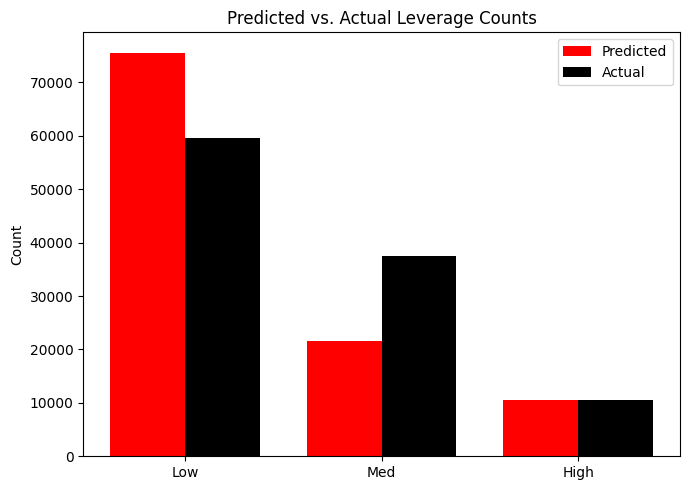


Confusion (rows=actual, cols=predicted):
pred        2      3     4
actual                    
2       50238   7477  1905
3       21751  12242  3538
4        3603   1871  5073


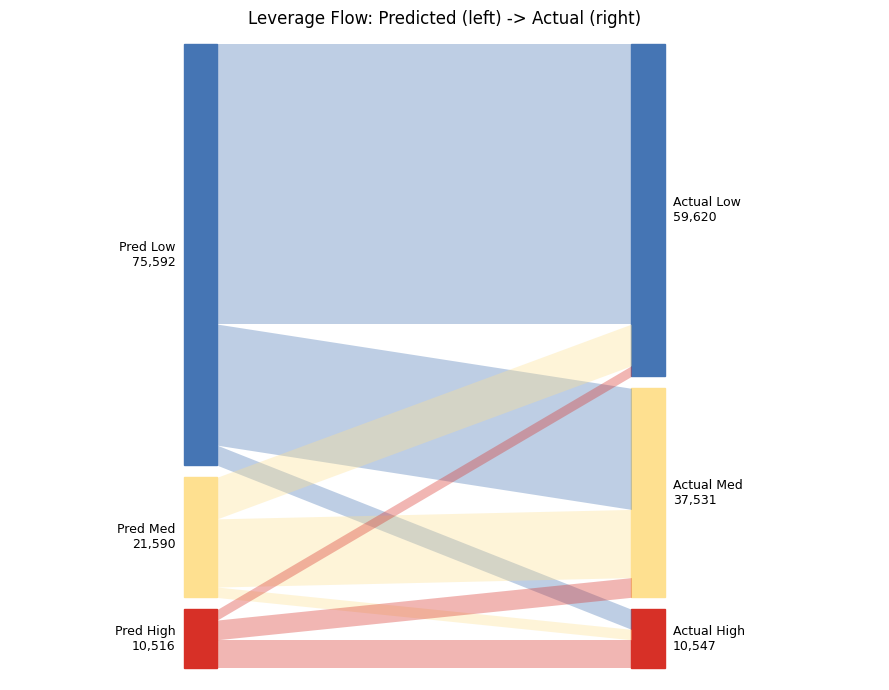

In [21]:
# Evaluation on the testing window (categorical leverage: 2=low, 3=med, 4=high).
proba = predict_leverage.predict_proba(X_test_df)
pred_class = np.array([2, 3, 4])[proba[:, [2, 3, 4]].argmax(axis=1)]
report = pd.DataFrame({'actual': y_test_np, 'pred': pred_class})
classes = [2, 3, 4]
class_labels = {2: 'Low', 3: 'Med', 4: 'High'}

# --- Predicted vs. actual total counts (overall, not the cross-tab) ---
counts = pd.DataFrame({
    'Predicted': report['pred'].value_counts().reindex(classes, fill_value=0),
    'Actual':    report['actual'].value_counts().reindex(classes, fill_value=0),
})
counts.index = [class_labels[c] for c in counts.index]
print('Predicted vs. Actual counts:')
print(counts)

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(classes)); w = 0.38
ax.bar(x - w/2, counts['Predicted'], w, label='Predicted', color='red')
ax.bar(x + w/2, counts['Actual'], w, label='Actual', color='black')
ax.set_xticks(x)
ax.set_xticklabels(counts.index)
ax.set_ylabel('Count')
ax.set_title('Predicted vs. Actual Leverage Counts')
ax.legend()
plt.tight_layout(); plt.show()

# --- Confusion (rows=actual, cols=predicted) ---
print('\nConfusion (rows=actual, cols=predicted):')
print(pd.crosstab(report['actual'], report['pred'], rownames=['actual'], colnames=['pred']))

# --- Flow diagram: predicted (left) -> actual (right) ---
# Each left segment is a predicted class; ribbons split it into the actual classes.
flow = pd.crosstab(report['pred'], report['actual']).reindex(index=classes, columns=classes, fill_value=0)

colors = {2: '#4575b4', 3: '#fee090', 4: '#d73027'}  # low/med/high
gap = flow.values.sum() * 0.02  # vertical gap between segments

left_tot  = flow.sum(axis=1)
right_tot = flow.sum(axis=0)

def segment_tops(totals):
    tops = {}; y = 0.0
    for c in classes:
        tops[c] = y; y += totals[c] + gap
    return tops
left_top  = segment_tops(left_tot)
right_top = segment_tops(right_tot)

fig, ax = plt.subplots(figsize=(9, 7))
x_left, x_right, bar_w = 0.0, 1.0, 0.08

# Draw predicted (left) and actual (right) bars
for c in classes:
    ax.add_patch(plt.Rectangle((x_left - bar_w, left_top[c]), bar_w, left_tot[c], color=colors[c]))
    ax.text(x_left - bar_w - 0.02, left_top[c] + left_tot[c]/2, f'Pred {class_labels[c]}\n{int(left_tot[c]):,}',
            ha='right', va='center', fontsize=9)
    ax.add_patch(plt.Rectangle((x_right, right_top[c]), bar_w, right_tot[c], color=colors[c]))
    ax.text(x_right + bar_w + 0.02, right_top[c] + right_tot[c]/2, f'Actual {class_labels[c]}\n{int(right_tot[c]):,}',
            ha='left', va='center', fontsize=9)

# Draw ribbons: from each predicted segment to each actual segment
left_cursor  = {c: left_top[c]  for c in classes}
right_cursor = {c: right_top[c] for c in classes}
for p in classes:           # predicted (left), stack ribbons within the segment
    for a in classes:       # actual (right)
        v = flow.loc[p, a]
        if v == 0:
            continue
        y0l, y1l = left_cursor[p], left_cursor[p] + v
        y0r, y1r = right_cursor[a], right_cursor[a] + v
        ys = np.linspace(0, 1, 50)
        smooth = ys*ys*(3 - 2*ys)  # smoothstep for curved ribbon
        xs = x_left + smooth * (x_right - x_left)
        top    = y0l + (y0r - y0l) * smooth
        bottom = y1l + (y1r - y1l) * smooth
        ax.fill_between(xs, bottom, top, color=colors[p], alpha=0.35, linewidth=0)
        left_cursor[p]  += v
        right_cursor[a] += v

ax.set_xlim(-0.5, 1.6)
ax.set_ylim(max(left_top[classes[-1]] + left_tot[classes[-1]],
                right_top[classes[-1]] + right_tot[classes[-1]]) + gap, -gap)
ax.axis('off')
ax.set_title('Leverage Flow: Predicted (left) -> Actual (right)')
plt.tight_layout(); plt.show()